In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import sem
import os

# Set the working directory
working_directory = "/Users/rainlam/Project/4.wingeiY/Depth/"
os.chdir(working_directory)

In [2]:
# cal M:F read depth ratio
def mf_cov_ratio(male_depth_list, female_depth_list):
    ############### males #######################
    male_cov_dfs = pd.DataFrame(columns=['CHR', 'START', 'END'])
    for i, male in enumerate(male_depth_list, start=1):
        male_cov_df = pd.read_csv(male + ".100kb.dep.txt", sep='\t')
        col_prefix =  f'{male}_male'
        male_cov_df = male_cov_df.rename(columns={'DEPTH': col_prefix})
        male_cov_dfs = male_cov_df if male_cov_df.empty else pd.merge(male_cov_dfs, male_cov_df, on=['CHR', 'START', 'END'], how='outer')
    # Calculate the average depth for each row
    male_cov_dfs['MALE_AVG'] = male_cov_dfs.filter(like='male').mean(axis=1)
    
    ################# females ##########################
    female_cov_dfs = pd.DataFrame(columns=['CHR', 'START', 'END'])
    for i, female in enumerate(female_depth_list, start=1):
        female_cov_df = pd.read_csv(female + ".100kb.dep.txt", sep='\t')
        col_prefix = f'{female}_female'
        female_cov_df = female_cov_df.rename(columns={'DEPTH': col_prefix})
        female_cov_dfs = female_cov_df if female_cov_df.empty else pd.merge(female_cov_dfs, female_cov_df, on=['CHR', 'START', 'END'], how='outer')
    # Calculate the average depth for each row
    female_cov_dfs['FEMALE_AVG'] = female_cov_dfs.filter(like='female').mean(axis=1)
    
    ################## M:F cov ratio ################
    overall_MF_ratios_df = pd.merge(male_cov_dfs, female_cov_dfs, on=['CHR', 'START', 'END'], how='outer')
    overall_MF_ratios_df['MALE_TO_FEMALE_RATIO'] = overall_MF_ratios_df['MALE_AVG'] / overall_MF_ratios_df['FEMALE_AVG']

    return male_cov_dfs, female_cov_dfs, overall_MF_ratios_df


# exe
# males = ["294_hap1",
#     "295_hap1",
#     "296_hap1"]

# females = ["291_hap1",
#     "292_hap1",
#     "293_hap1"]

# result_df, df2, df3 = overall_cov(males, females)

# print(df3)

############### real data #################
# Function to retrieve data

def get_data(mf_cov_ratio_df, targetRow):
    mf_cov_ratio_df['mid'] = (mf_cov_ratio_df['START'] + mf_cov_ratio_df['END']) / 2
    # chromosome names
    chromosome_mapping = {}
    chr_origin_id = mf_cov_ratio_df['CHR'].unique().tolist()
    # rename the chromosome
    """
    {'h1tg000001l': 1,
     'h1tg000002l': 2,
     'h1tg000003l': 3,
     ...
     }
    """
    for i in range(len(chr_origin_id)):
        chromosome_mapping[chr_origin_id[i]] = i + 1

    # Replace the values in the 'CHR' column using the mapping
    mf_cov_ratio_df['CHR'] =  mf_cov_ratio_df['CHR'].replace(chromosome_mapping)
    mf_cov_ratio_df['Position'] = range(1, len(mf_cov_ratio_df) + 1)

    chromosome_offsets = {1: 0}
    for chrom in mf_cov_ratio_df['CHR'].unique()[:-1]:
        chrom_data = mf_cov_ratio_df[mf_cov_ratio_df['CHR'] == chrom]
        offset = chrom_data['END'].max()  # Adjust if needed based on your data
        chromosome_offsets[chrom + 1] = offset

    # Create a cumulative dictionary
    cumulative_offsets = {}
    cumulative_value = 0

    for chrom_id, offset_value in chromosome_offsets.items():
        cumulative_value += offset_value
        cumulative_offsets[chrom_id] = cumulative_value

    mf_cov_ratio_df['new_pos'] = mf_cov_ratio_df['CHR'].map(cumulative_offsets) + mf_cov_ratio_df['mid']

    chromosomes = mf_cov_ratio_df['CHR']
    positions = mf_cov_ratio_df['new_pos']
    depth_values = mf_cov_ratio_df[targetRow]
    return chromosomes, positions, depth_values




# Your plotting code...
# Function to plot Manhattan plot
def plot_manhattan(ax, chromosomes, positions, p_values):
    num_chromosomes = len(chromosomes.unique())

    colors = ['grey','orange'] * (num_chromosomes + 1)
#     colors = ['grey'] * (num_chromosomes + 1)

    for chrom in range(1, num_chromosomes + 1):
        chrom_positions = positions[chromosomes == chrom]
        chrom_p_values = p_values[chromosomes == chrom]
        color_index = chrom - 1
        ax.plot(chrom_positions, chrom_p_values, color=colors[color_index],label=f'Chromosome {chrom}')
#         ax.plot(chrom_positions, chrom_p_values, color=colors[color_index], s=5, label=f'Chromosome {chrom}')


    # Calculate midpoints for x-axis labels
    midpoints = [np.mean(positions[chromosomes == chrom]) for chrom in range(1, num_chromosomes + 1)]

#     ax.set_xlabel('Chromosome')
    ax.set_ylabel('Coverage')
    ax.set_xticks(midpoints)
    ax.set_ylim(0,2)
    #ax.axvspan(min(positions), max(positions), ymin=lower_bound, ymax=upper_bound, color='gray', alpha=0.9)
    ax.set_xticklabels([f'{i + 1}' for i in range(num_chromosomes)])
    ax.margins(x=0.01, y=0.01)
    


Text(0.5, 0, 'Chromosomes (Hap2)')

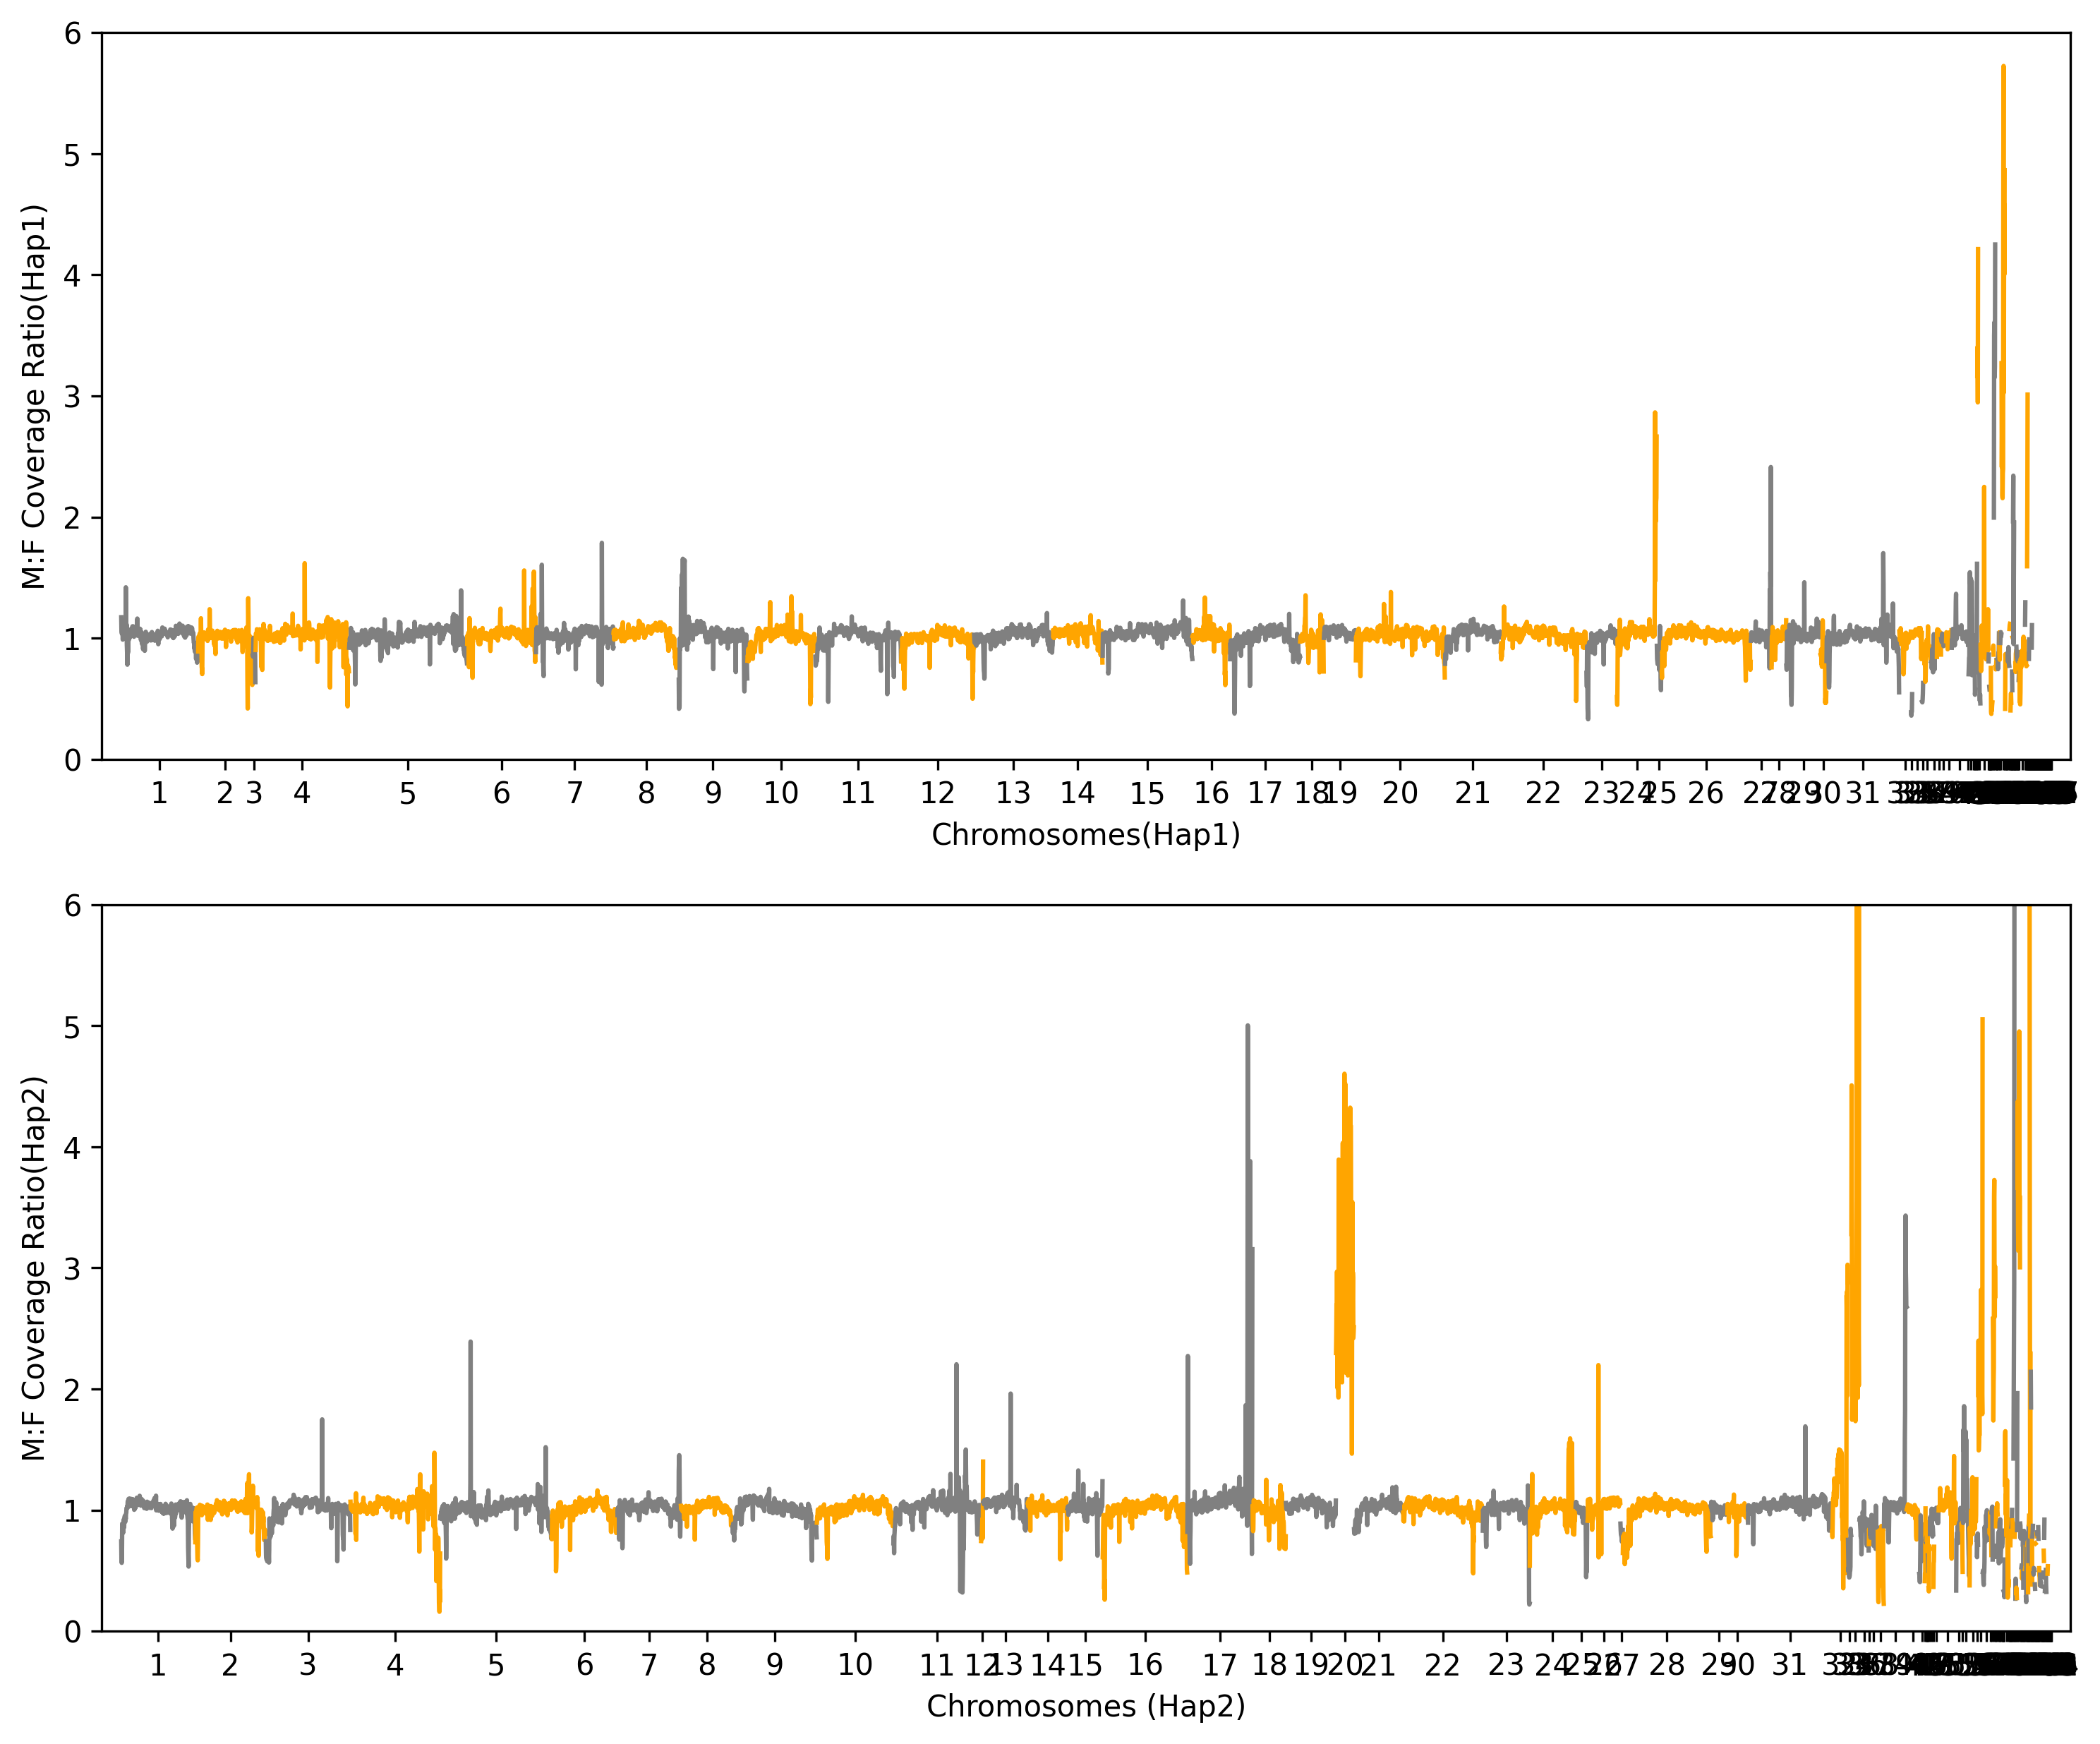

In [3]:
path = "/Users/rainlam/Project/4.wingeiY/Depth"
# Create a new figure and axis
fig, axs = plt.subplots(2,1,figsize=(12, 10), dpi=300)

males_hap1 = ["294_hap1",
    "295_hap1",
    "296_hap1"]

females_hap1 = ["291_hap1",
    "292_hap1",
    "293_hap1"]

male_cov_dfs, female_cov_dfs, mf_cov_ratio_df = mf_cov_ratio(males_hap1, females_hap1)
mf_cov_ratio_df.to_csv("/Users/rainlam/Desktop/mf_cov_ratio_hap1.csv",sep="\t", index=False)

chromosomes, positions, depth_values = get_data(mf_cov_ratio_df, "MALE_TO_FEMALE_RATIO")
chromosomes_2, positions_2, depth_values_2 = get_data(male_cov_dfs,"MALE_AVG")
chromosomes_3, positions_3, depth_values_3 = get_data(female_cov_dfs, "FEMALE_AVG")

plot_manhattan(axs[0], chromosomes, positions, depth_values)
axs[0].set_ylim(0,6)
axs[0].set_ylabel('M:F Coverage Ratio(Hap1)')
axs[0].set_xlabel('Chromosomes(Hap1)')
#     axs[x-1].set_xlabel('Chromosome'.format(y))

males_hap2 = ["294_hap2",
    "295_hap2",
    "296_hap2"]

females_hap2 = ["291_hap2",
    "292_hap2",
    "293_hap2"]

male_cov_dfs, female_cov_dfs, mf_cov_ratio_df = mf_cov_ratio(males_hap2, females_hap2)
mf_cov_ratio_df.to_csv("/Users/rainlam/Desktop/mf_cov_ratio_hap2.csv",sep="\t", index=False)
chromosomes, positions, depth_values = get_data(mf_cov_ratio_df, "MALE_TO_FEMALE_RATIO")
chromosomes_2, positions_2, depth_values_2 = get_data(male_cov_dfs,"MALE_AVG")
chromosomes_3, positions_3, depth_values_3 = get_data(female_cov_dfs, "FEMALE_AVG")
plot_manhattan(axs[1], chromosomes, positions, depth_values)
axs[1].set_ylim(0,6)
axs[1].set_ylabel('M:F Coverage Ratio(Hap2)')
axs[1].set_xlabel('Chromosomes (Hap2)')
# axs[1].invert_xaxis() #flip y axis
# axs[1].invert_yaxis() #flip x axis
# Adjust ax1 or use ax2, ax3 for additional plots
# Label each subplot as A, B, C, D
# pops = ['Aripo','Quare','Yarra']
# for i, ax in enumerate(axs):
#     ax.text(-0.065, 1, f'{chr(65 + i)}', transform=ax.transAxes, fontsize=12, fontweight='bold', va='top')
#     axs[x-1].text(0.78, 0.95, f'{pops[i]}, average={pi_avgs[i]:.4f}\n95% CIs [{lower_bounds[i]}, {upper_bounds[i]}]', transform=ax.transAxes, fontsize=10, va='top')

# # plt.tight_layout()
# plt.savefig("/Users/rainlam/Desktop/fst.pdf", format='pdf', bbox_inches='tight')
# plt.show()

Text(0, 0.5, 'Read depth')

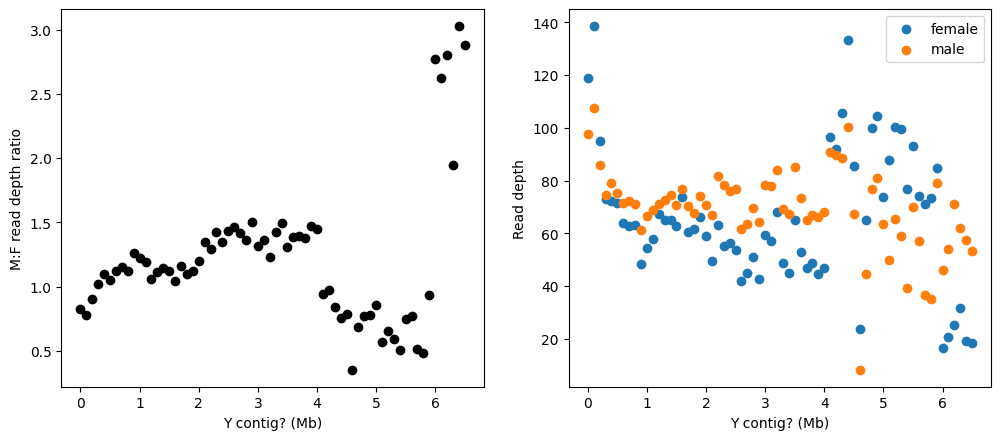

In [4]:
import math
fig, axs = plt.subplots(1,2,figsize=(12, 5), dpi=100)
male_cov_dfs, female_cov_dfs, mf_cov_ratio_df = mf_cov_ratio(males_hap2, females_hap2)

chr_df = mf_cov_ratio_df[mf_cov_ratio_df["CHR"]=="h2tg000032l"]
chr_df["MALE_TO_FEMALE_RATIO"].apply(lambda x: float(x))
axs[0].scatter(chr_df["START"]/1e6, chr_df["MALE_TO_FEMALE_RATIO"], color="black")

axs[0].set_xlabel("Y contig? (Mb)")
axs[0].set_ylabel("M:F read depth ratio")
axs[1].scatter(chr_df["START"]/1e6, chr_df["FEMALE_AVG"], label="female")
axs[1].scatter(chr_df["START"]/1e6, chr_df["MALE_AVG"], label="male")
axs[1].legend()
# axs[1].set_ylim(60,80)
axs[1].set_xlabel("Y contig? (Mb)")
axs[1].set_ylabel("Read depth")
# plt.plot(chr_df["START"], chr_df["MALE_TO_FEMALE_RATIO"])
# male_cov_dfs, female_cov_dfs, mf_cov_ratio_df = mf_cov_ratio(males_hap1, females_hap1)

# chr_df = mf_cov_ratio_df[mf_cov_ratio_df["CHR"]=="h1tg000027l"]
# plt.scatter(chr_df["START"], chr_df["MALE_TO_FEMALE_RATIO"])

/var/folders/k1/dzck1_8d2yg0gqs1qgxpnxnm0000gn/T/ipykernel_34954/467258955.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chr_df["MALE_TO_FEMALE_RATIO"] = chr_df["MALE_TO_FEMALE_RATIO"].astype(float)


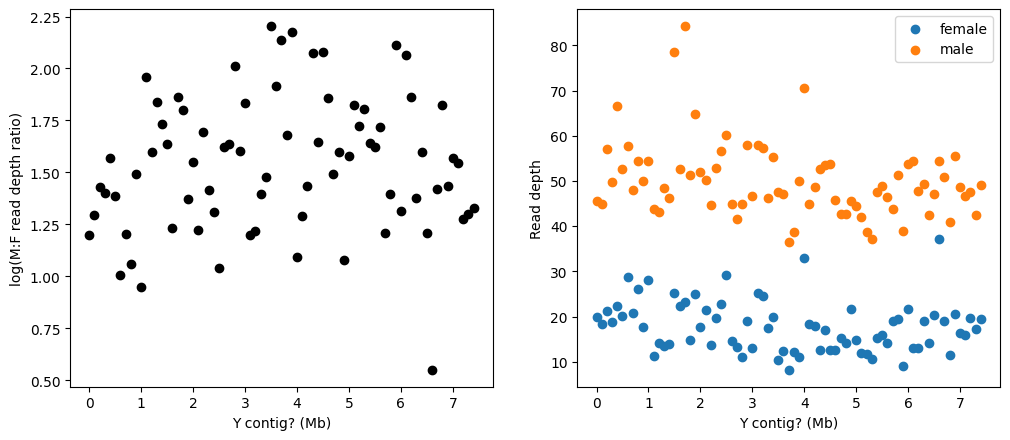

In [5]:

fig, axs = plt.subplots(1, 2, figsize=(12, 5), dpi=100)
male_cov_dfs, female_cov_dfs, mf_cov_ratio_df = mf_cov_ratio(males_hap2, females_hap2)

chr_df = mf_cov_ratio_df[mf_cov_ratio_df["CHR"] == "h2tg000020l"]
chr_df["MALE_TO_FEMALE_RATIO"] = chr_df["MALE_TO_FEMALE_RATIO"].astype(float)
axs[0].scatter(chr_df["START"] / 1e6, np.log2(chr_df["MALE_TO_FEMALE_RATIO"]), color="black")

axs[0].set_xlabel("Y contig? (Mb)")
axs[0].set_ylabel("log(M:F read depth ratio)")

axs[1].scatter(chr_df["START"] / 1e6, chr_df["FEMALE_AVG"], label="female")
axs[1].scatter(chr_df["START"] / 1e6, chr_df["MALE_AVG"], label="male")
axs[1].legend()
axs[1].set_xlabel("Y contig? (Mb)")
axs[1].set_ylabel("Read depth")

plt.show()

In [5]:
mf_cov_ratio_df

,CHR,START,END,294_hap2_male,295_hap2_male,296_hap2_male,MALE_AVG,291_hap2_female,292_hap2_female,293_hap2_female,FEMALE_AVG,MALE_TO_FEMALE_RATIO
0,h2tg000001l,1,100001,160.897380,173.169530,253.978530,196.015147,156.345830,240.397770,396.678630,264.474077,0.741151
1,h2tg000001l,100001,200001,63.363760,61.439450,41.646420,55.483210,65.974170,71.291050,151.904960,96.390060,0.575611
2,h2tg000001l,200001,300001,61.949540,60.165160,42.151810,54.755503,65.621540,72.934390,152.464560,97.006830,0.564450
3,h2tg000001l,300001,400001,112.908010,91.396010,65.577320,89.960447,90.182300,117.745850,215.653390,141.193847,0.637141
4,h2tg000001l,400001,500001,73.259540,89.555530,71.312270,78.042447,77.963080,80.130010,105.576480,87.889857,0.887957
...,...,...,...,...,...,...,...,...,...,...,...,...
8045,h2tg000151l,1,100001,38.743927,30.743760,29.499368,32.995685,45.613744,35.675175,35.961764,39.083561,0.844234
8046,h2tg000152l,1,100001,188.903229,213.031614,353.889811,251.941551,177.026331,295.878155,468.490231,313.798239,0.802878
8047,h2tg000153l,1,100001,195.924006,200.539825,334.913423,243.792418,164.162014,288.331059,448.137854,300.210309,0.812072
8048,h2tg000154l,1,100001,49.060067,61.356990,51.777417,54.064824,56.859726,35.572516,33.709500,42.047247,1.285811


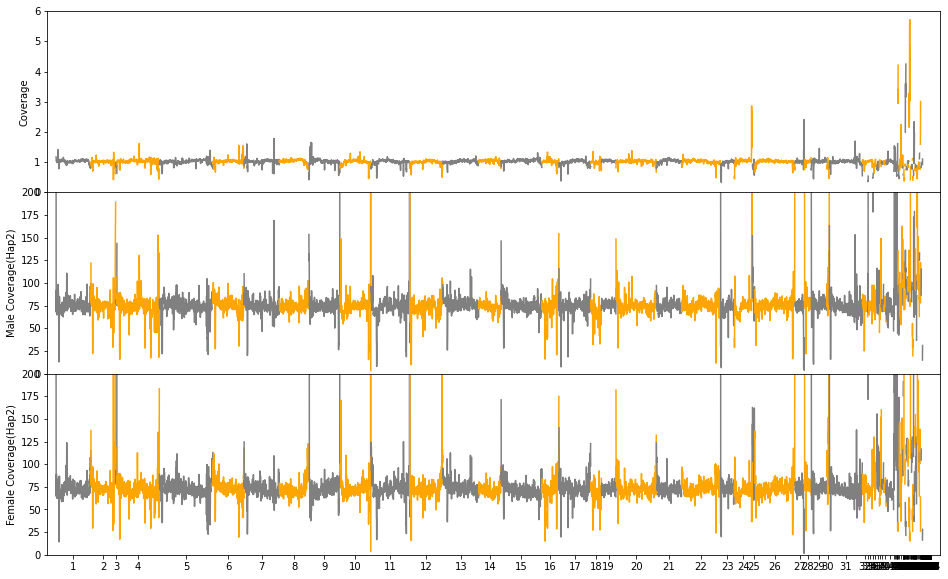

In [6]:
male_cov_dfs, female_cov_dfs, mf_cov_ratio_df = mf_cov_ratio(males_hap1, females_hap1)

chromosomes_1, positions_1, depth_values_1 = get_data(mf_cov_ratio_df, "MALE_TO_FEMALE_RATIO")
chromosomes_2, positions_2, depth_values_2 = get_data(male_cov_dfs, "MALE_AVG")
chromosomes_3, positions_3, depth_values_3 = get_data(female_cov_dfs, "FEMALE_AVG")

# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(16, 10))

# Plot the first plot on the top
plot_manhattan(axs[0], chromosomes_1, positions_1, depth_values_1)
axs[0].set_ylim(0, 6)
axs[1].set_ylabel('M:F Coverage Ratio(Hap2)')

# Plot the second plot on the bottom
plot_manhattan(axs[1], chromosomes_2, positions_2, depth_values_2)
axs[1].set_ylim(0, 200)
axs[1].set_ylabel('Male Coverage(Hap2)')
# axs[1].set_xlabel('Chromosomes (Hap2)')

# Flip the y-axis for the second plot
# axs[1].invert_yaxis()
plot_manhattan(axs[2], chromosomes_3, positions_3, depth_values_3)
axs[2].set_ylim(0, 200)
axs[2].set_ylabel('Female Coverage(Hap2)')
# axs[2].invert_yaxis()
# Share the x-axis
plt.subplots_adjust(hspace=0)  # Adjust the vertical space between subplots
plt.show()

0         1
1         1
2         1
3         1
4         1
       ... 
7550    183
7551    184
7552    185
7553    186
7554    187
Name: CHR, Length: 7555, dtype: int64

(0.0, 300.0)

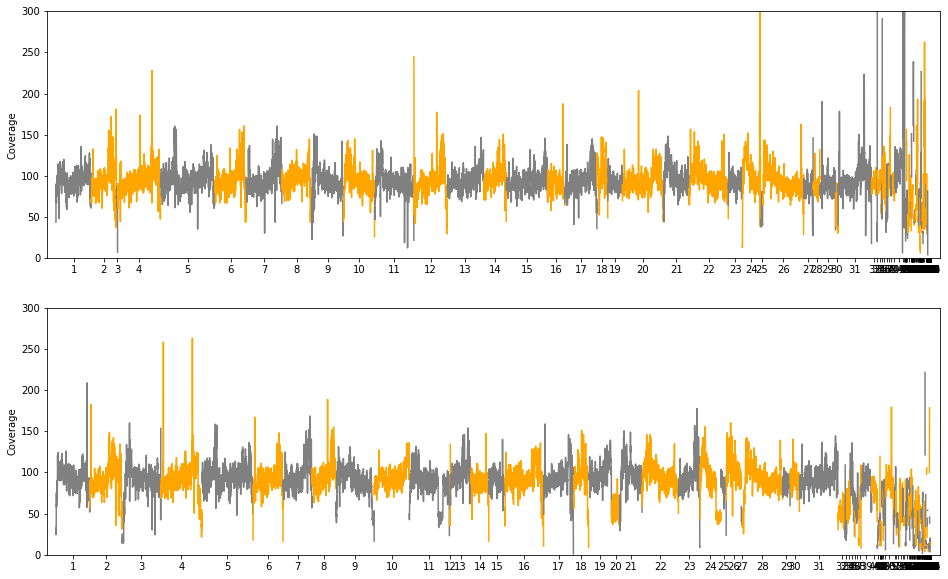

In [34]:
fig, axs = plt.subplots(2, 1, figsize=(16, 10))
df_pbcss_hap2 = pd.read_csv("/Users/rainlam/hap2_100k.cov.regions.bed", sep = '\t', names=["CHR","START","END","DEP"])
chr2, pos2, value2 = get_data(df_pbcss_hap2, "DEP")
plot_manhattan(axs[1], chr2, pos2, value2)
axs[1].set_ylim(0, 300)

df_pbcss_hap1 = pd.read_csv("/Users/rainlam/hap1_100k.regions.bed", sep = '\t', names=["CHR","START","END","DEP"])
chr1, pos1, value1 = get_data(df_pbcss_hap1, "DEP")
plot_manhattan(axs[0], chr1, pos1, value1)
axs[0].set_ylim(0, 300)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assuming you have DataFrames df, df2, df3, df4, df5, and df6

# Perform the operation
new_np_array = (np.array(df['DEPTH']) + np.array(df2['DEPTH']) + np.array(df3['DEPTH'])) / \
               (np.array(df4['DEPTH']) + np.array(df5['DEPTH']) + np.array(df6['DEPTH']))

# Plot the resulting values
plt.figure(figsize=(10, 6))
plt.plot(new_np_array, label='Resulting Values')

plt.xlabel('Index')
plt.ylabel('Result')
plt.title('Result of the Operation')
plt.legend()

plt.show()


NameError: name 'df' is not defined

In [ ]:
pd.merge(df, df2, on=['CHR', 'START', 'END'], how='outer')

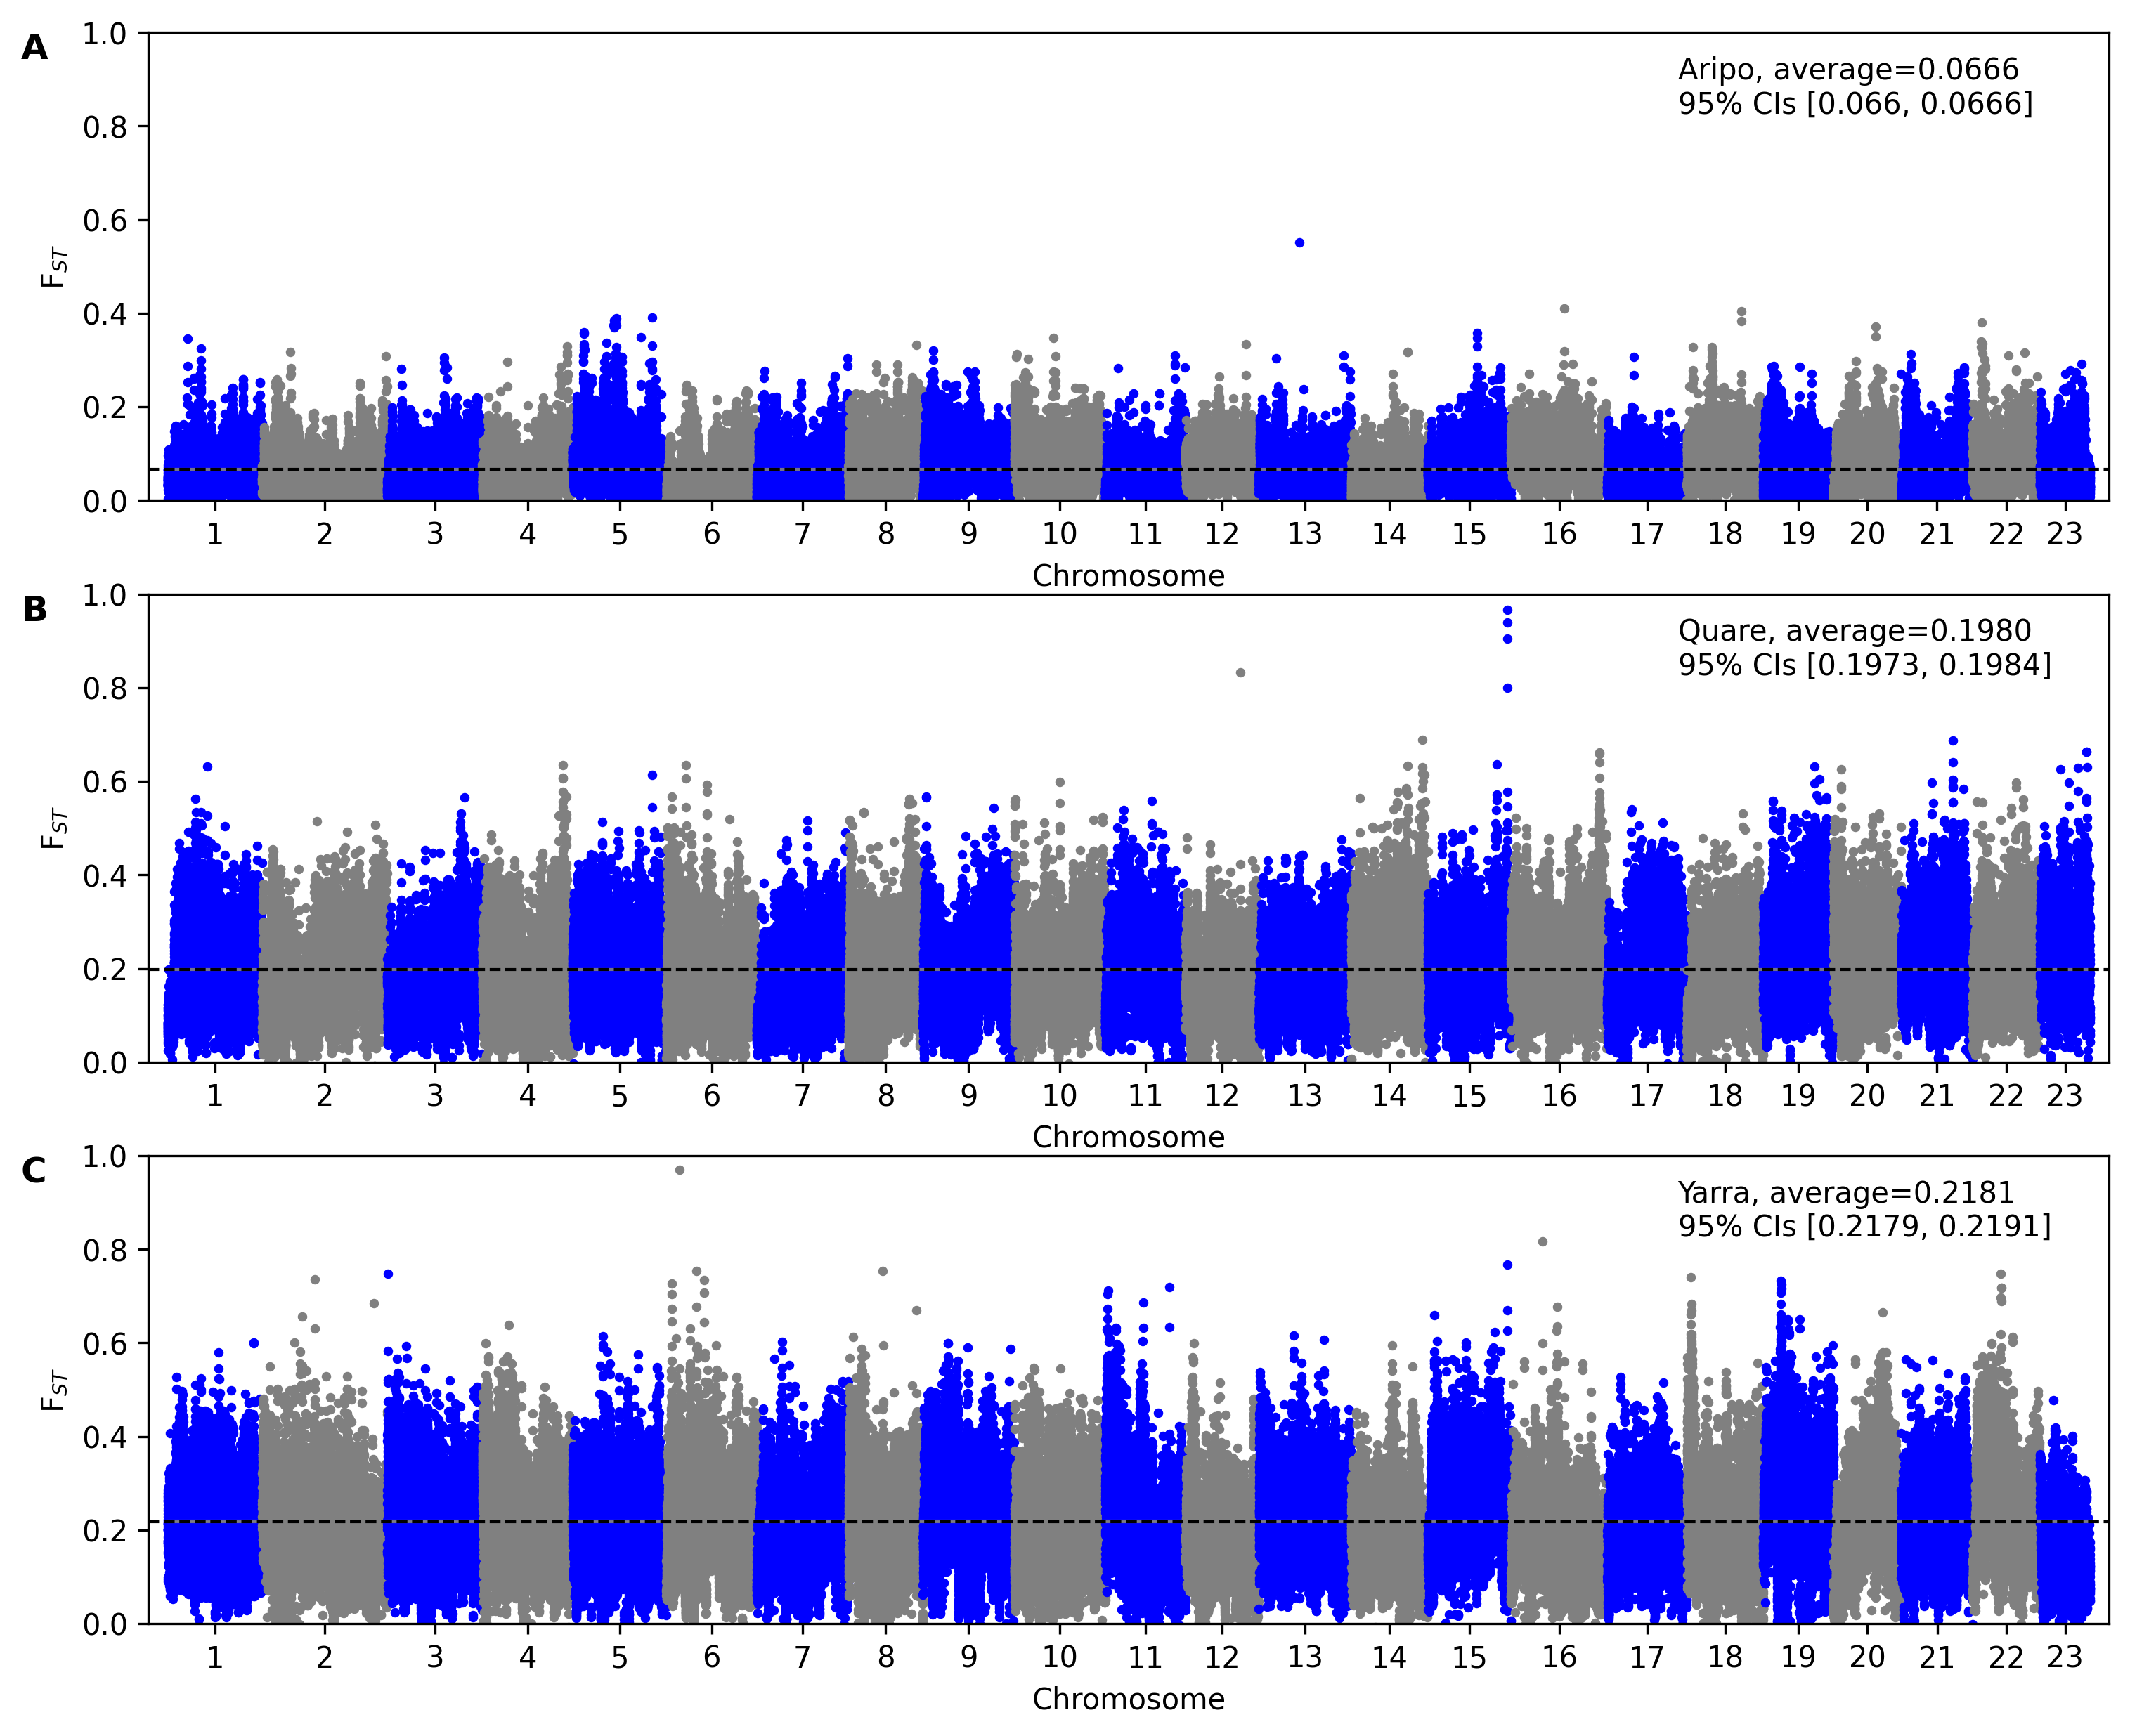

In [108]:
# Create a new figure and axis
fig, axs = plt.subplots(3, 1, figsize=(12, 10), dpi=300)

pi_avgs = []
lower_bounds = []
upper_bounds = []
# Retrieve data using the get_data function
for x,y in zip([1,2,3],['ARH_ARL','QUH_QUL','YAH_YAL']):
    chromosomes, positions, p_values = get_data('./{}.10k_5k.windowed.weir.fst'.format(y))
    avg, lower_bound, upper_bound = CIs(p_values)
    plot_manhattan(axs[x-1], chromosomes, positions, p_values, lower_bound, upper_bound)
    avg = (p_values.sum()/len(p_values)).round(4)
    pi_avgs.append(avg)
    lower_bounds.append(lower_bound.round(4))
    upper_bounds.append(upper_bound.round(4))
    axs[x-1].set_xlabel('Chromosome'.format(y))
    axs[x-1].axhline(y=avg, color='black', linestyle='--', linewidth=1)
    
# Adjust ax1 or use ax2, ax3 for additional plots
# Label each subplot as A, B, C, D
pops = ['Aripo','Quare','Yarra']
for i, ax in enumerate(axs):
    ax.text(-0.065, 1, f'{chr(65 + i)}', transform=ax.transAxes, fontsize=12, fontweight='bold', va='top')
    axs[x-1].text(0.78, 0.95, f'{pops[i]}, average={pi_avgs[i]:.4f}\n95% CIs [{lower_bounds[i]}, {upper_bounds[i]}]', transform=ax.transAxes, fontsize=10, va='top')

# plt.tight_layout()
plt.savefig("/Users/rainlam/Desktop/fst.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [109]:
###### make boxplots
_,_, ARH_ARL_p_values = get_data('ARH_ARL.10k_5k.windowed.weir.fst')
_,_, QUH_QUL_p_values = get_data('QUH_QUL.10k_5k.windowed.weir.fst')
_,_, YAH_YAL_p_values = get_data('YAH_YAL.10k_5k.windowed.weir.fst')

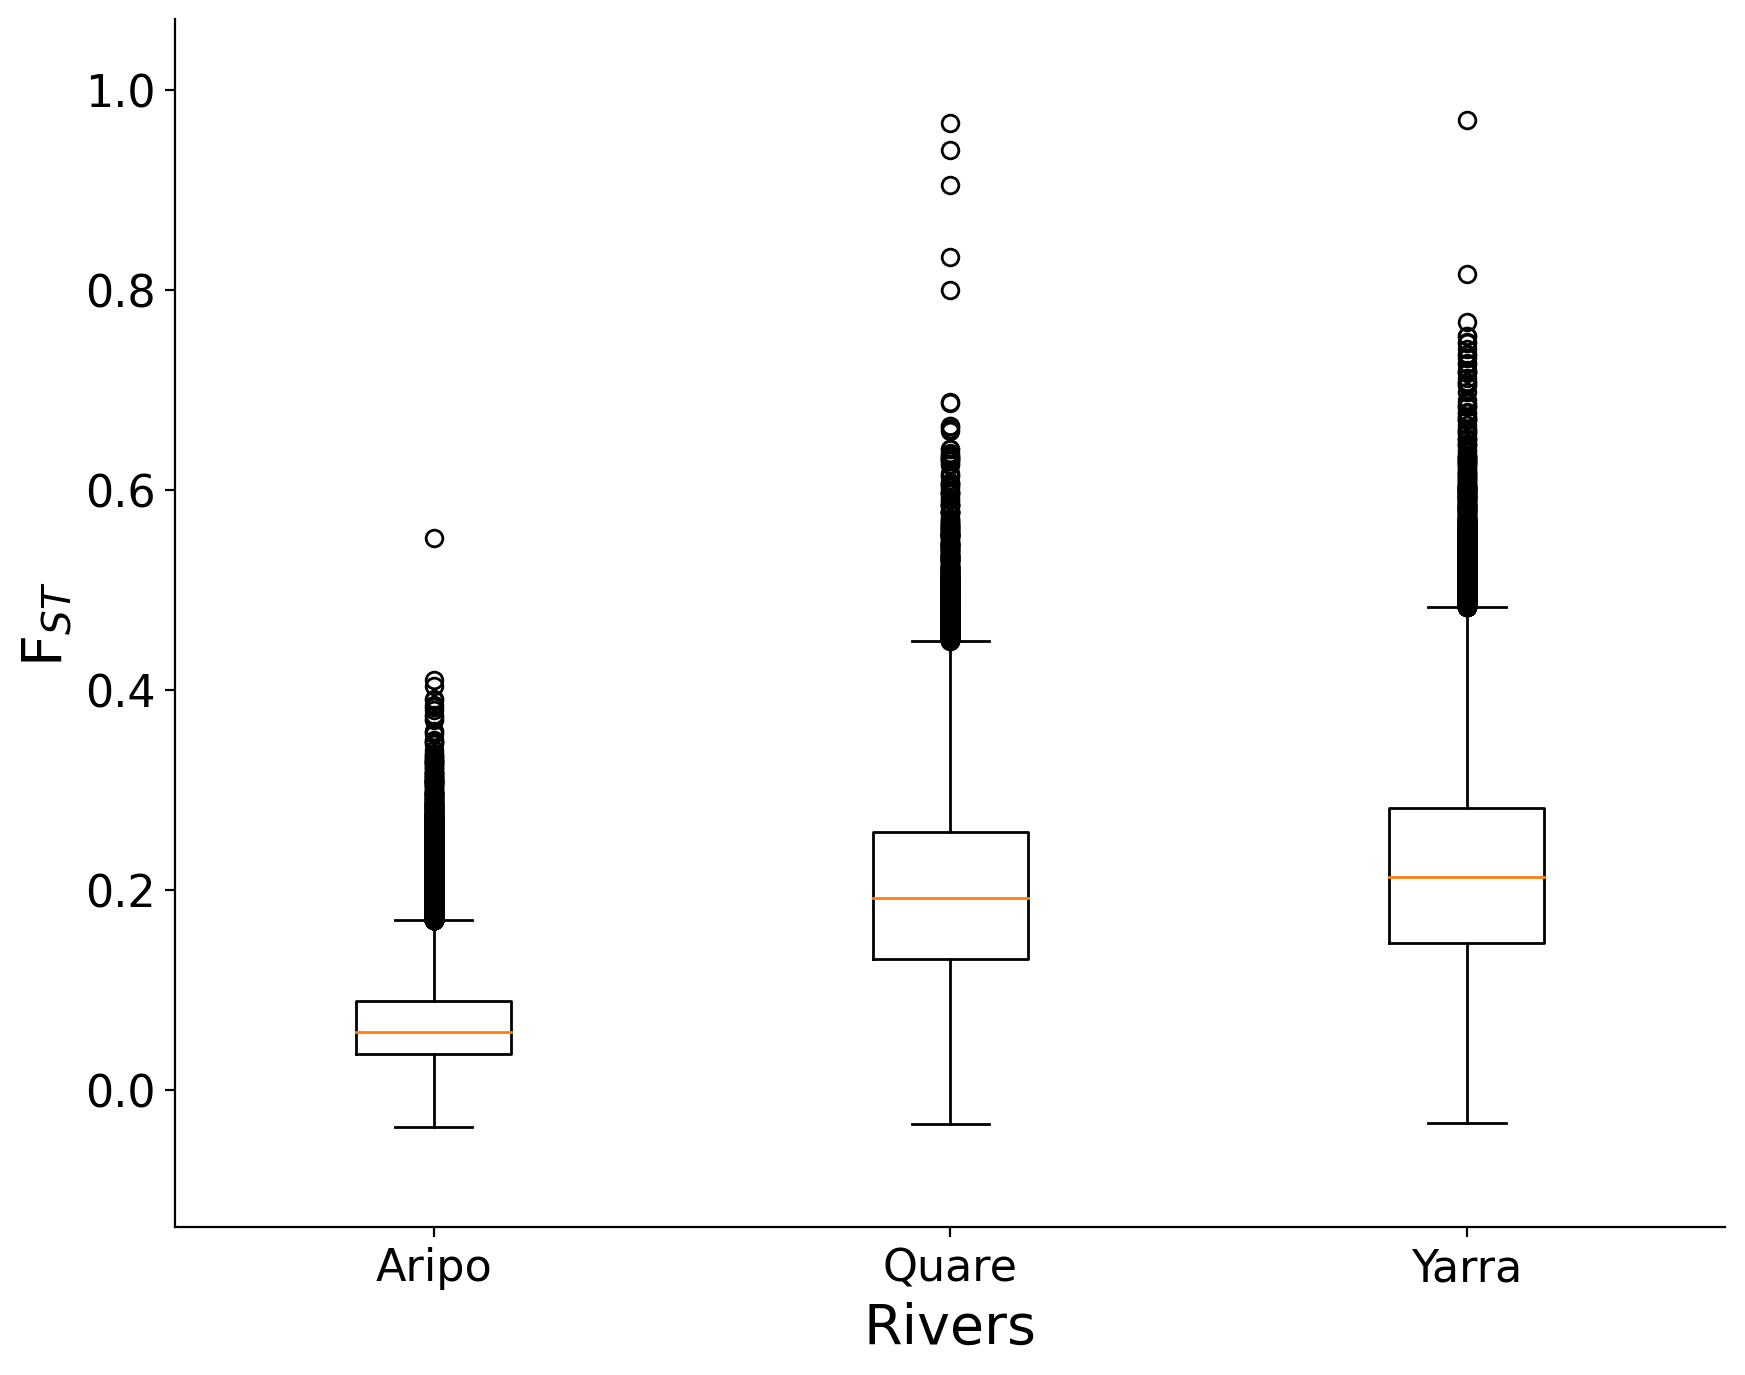

In [142]:
import matplotlib.pyplot as plt
import numpy as np

# Generating random data for three groups

data = [ARH_ARL_p_values, 
        QUH_QUL_p_values, 
        YAH_YAL_p_values]

# Creating a boxplot for the three groups
plt.figure(figsize=(10, 8),dpi=200)
plt.boxplot(data, labels=['Aripo', 'Quare', 'Yarra'])
plt.xlabel('Rivers',fontsize=20)
plt.ylabel('F$_{ST}$',fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=16)
#plt.ylim(0,1.0)
plt.yticks(ticks=[0.0, .2, .4, .6, .8, 1.0], labels=['0.0', '0.2', '0.4', '0.6', '0.8', '1.0'])
# Making the spines visible
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.margins(x=0.1, y=0.1)
plt.show()


In [ ]:
### You might want to use the following code at some points
def CIs(p_values):
    # Given mean FST values
    mean_fst_values = p_values

    # Number of resamples
    num_resamples = 1000

    # Empty list to store resampled means
    resampled_means = []

    # Perform bootstrapping
    for _ in range(num_resamples):
        # Resample with replacement
        resample = np.random.choice(mean_fst_values, size=100, replace=True)

        # Calculate mean of the resample
        resampled_mean = np.mean(resample)
        resampled_means.append(resampled_mean)

    # Calculate statistics for resampled means
    resampled_means = np.array(resampled_means)
    mean_of_resampled_means = np.mean(resampled_means)
    std_err_of_resampled_means = sem(resampled_means)

    # Calculate the confidence interval for the resampled means
    margin_of_error = 1.96 * std_err_of_resampled_means
    lower_bound = mean_of_resampled_means - margin_of_error
    upper_bound = mean_of_resampled_means + margin_of_error
    
    return mean_of_resampled_means, lower_bound, upper_bound